Vamos a realizar una prediccion del precio del bitcoin para el proximo año. Usando un modelo de Monte Carlo y Bootstrapping.

In [1]:
#importar librerias necesarias
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from numpy import random as rn
from scipy import stats
import seaborn as sns
from pandas_datareader import data as pdr
import yfinance as yf
from datetime import datetime

In [2]:
#pip install pandas_datareader
#from pandas_datareader import data as pdr
#pip install yfinance
#import yfinance as yf

#from datetime import datetime 

#start_time = datetime.now()  #fecha y hora de hoy

#from datetime import datetime

# objeto datetime que contiene la fecha y hora actuales
#now = datetime.now()
#dt_string = now.strftime("%d/%m/%Y")

In [3]:
#Ticker = "BTC-USD"
#Start_Date = "2024-03-01"
#End_Date = "2025-03-01"
#data = yf.download(Ticker, Start_Date, End_Date)

In [4]:
data = pd.read_csv('bitcoin.csv')

In [5]:
data.head(5)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


In [6]:
#hacemos una copia de la base de datos y excluimos las columnas que no necesitamos
df = data.copy()
df.drop(["Open", "High", "Low", "Close","Volume"],axis=1,inplace=True)
df.rename(columns={"Adj Close": "Price"},inplace=True)
df

,Date,Price
0,2014-09-17,457.334015
1,2014-09-18,424.440002
2,2014-09-19,394.795990
3,2014-09-20,408.903992
4,2014-09-21,398.821014
...,...,...
2708,2022-02-15,44575.203125
2709,2022-02-16,43961.859375
2710,2022-02-17,40538.011719
2711,2022-02-18,40030.976563


In [7]:
df["Return"] = 0.0
for x in range(len(df["Price"])-1):
    df["Return"][x]=np.log(df["Price"].iloc[x]/df["Price"].iloc[x+1])
df = df.reindex(index=df.index[::-1])
df

C:\Users\Ximena Quiroga\AppData\Local\Temp\ipykernel_21680\1283243496.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Return"][x]=np.log(df["Price"].iloc[x]/df["Price"].iloc[x+1])


,Date,Price,Return
2712,2022-02-19,40126.429688,0.000000
2711,2022-02-18,40030.976563,-0.002382
2710,2022-02-17,40538.011719,0.012587
2709,2022-02-16,43961.859375,0.081082
2708,2022-02-15,44575.203125,0.013855
...,...,...,...
4,2014-09-21,398.821014,-0.008317
3,2014-09-20,408.903992,0.024968
2,2014-09-19,394.795990,-0.035111
1,2014-09-18,424.440002,0.072402


In [8]:
#Retornos diarios
s1 = []
for x in range(1,len(df["Price"])):
    s1.append(df["Return"][x])
df1 = pd.DataFrame({"Daily Return": s1})
df1.T

,0,1,2,3,4,5,6,7,8,9,...,2702,2703,2704,2705,2706,2707,2708,2709,2710,2711
Daily Return,0.072402,-0.035111,0.024968,-0.008317,-0.080333,0.029306,0.027868,0.017523,0.012202,0.057539,...,0.026921,0.003862,0.001112,-0.009186,-0.045631,0.013855,0.081082,0.012587,-0.002382,0.0


In [9]:
#vamos a seleccionar un numero aleatorio entre el 0 y 365
M=int(5000)
T=1
N=252 #se escoge el 252
h=T/N
u=1e-11*h

In [10]:
u

3.9682539682539676e-14

Creamos una matriz de 5000 filas × 252 columnas para los números aleatorios entre 0 y 365.
El número de filas representa el número de pruebas, mientras que el número de columnas representa el número de días comerciales (no todos los dias opera la bolsa).

In [11]:
Number = np.ones((M,N))
Number

array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]])

Creamos una matriz de 5000 filas × 252 columnas para los rendimientos futuros del Bitcoin. El número de filas representa el número de pruebas, mientras que el número de columnas representa el número de días comerciales (no todos los dias opera la bolsa).

In [12]:
Return = np.zeros((M,N))
Return

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

Ahora, vamos a revisar el precio del Bitcoin al dia siguiente:

In [14]:
day_data = data.tail(1)

In [18]:
S0 = day_data["Adj Close"].iloc[0]
#S0 = S0[1]
S0

40126.429688

Ahora, creamos una matriz con el nombre de Bitcoin y el precio del Bitcoin el 19 de octubre de 2024, con 5000 filas y 252 columnas.

In [19]:
Bitcoin = S0*np.ones((M,N+1))
Bitcoin

array([[40126.429688, 40126.429688, 40126.429688, ..., 40126.429688,
        40126.429688, 40126.429688],
       [40126.429688, 40126.429688, 40126.429688, ..., 40126.429688,
        40126.429688, 40126.429688],
       [40126.429688, 40126.429688, 40126.429688, ..., 40126.429688,
        40126.429688, 40126.429688],
       ...,
       [40126.429688, 40126.429688, 40126.429688, ..., 40126.429688,
        40126.429688, 40126.429688],
       [40126.429688, 40126.429688, 40126.429688, ..., 40126.429688,
        40126.429688, 40126.429688],
       [40126.429688, 40126.429688, 40126.429688, ..., 40126.429688,
        40126.429688, 40126.429688]])

In [20]:
#seleccionamos un numero aleatorio entre 0 y 365 para hallar su retorno diario
a = rn.randint(0,365)
a

120

In [21]:
df1["Daily Return"].iloc[a]

0.04339383762572508

In [22]:
for x in range(0,M):
    for y in range(0,N):
        a = rn.randint(0,365)
        Number[x,y] = a
        Return[x,y] = df1['Daily Return'].iloc[a]
Number

array([[135., 186., 328., ...,  81., 293., 301.],
       [330.,  28.,   2., ..., 299., 243., 197.],
       [327., 235., 281., ..., 211., 307., 260.],
       ...,
       [163., 196., 276., ..., 131., 330.,  27.],
       [226.,   5., 322., ..., 316., 210., 336.],
       [128., 173.,  64., ..., 219., 141., 193.]])

In [23]:
len(Number)

5000

In [24]:
Return

array([[-0.04279332,  0.08259052,  0.00865683, ...,  0.02713967,
         0.00576657, -0.00496089],
       [ 0.01566328, -0.00313709,  0.02496766, ...,  0.00570383,
        -0.00888913,  0.00246054],
       [ 0.01494165,  0.00432887, -0.02991024, ..., -0.00212442,
         0.00424015, -0.00296072],
       ...,
       [-0.02308907, -0.00519193, -0.01240918, ...,  0.11900074,
         0.01566328,  0.03143589],
       [-0.02284192,  0.02930607, -0.00361184, ...,  0.01076911,
         0.02521312,  0.01188684],
       [-0.0234118 , -0.01570745, -0.00588838, ...,  0.03122593,
        -0.0243912 ,  0.0134298 ]])

In [25]:
z = Number[0,0]
z

135.0

In [26]:
df1.loc[z]

Daily Return   -0.042793
Name: 135, dtype: float64

In [27]:
for i in range(0,N):
    Bitcoin[:,i+1] = Bitcoin[:,i]*(1+Return[:,i])
    
Bitcoin

array([[ 40126.429688  ,  38409.28657097,  41581.52959365, ...,
         34719.12386734,  34919.33411633,  34746.10320276],
       [ 40126.429688  ,  40754.94105789,  40627.08924633, ...,
         28684.03414084,  28429.05792682,  28499.00873476],
       [ 40126.429688  ,  40725.98455978,  40902.28207281, ...,
         37865.27283312,  38025.82723558,  37913.24337408],
       ...,
       [ 40126.429688  ,  39199.94763683,  38996.42412994, ...,
         85934.11686796,  87280.12671566,  90023.85550251],
       [ 40126.429688  ,  39209.86502067,  40358.95213635, ...,
         21797.54696353,  22347.13121851,  22612.7679504 ],
       [ 40126.429688  ,  39186.99767667,  38571.46974515, ...,
        162550.8779424 , 158586.06688327, 160715.8457565 ]])

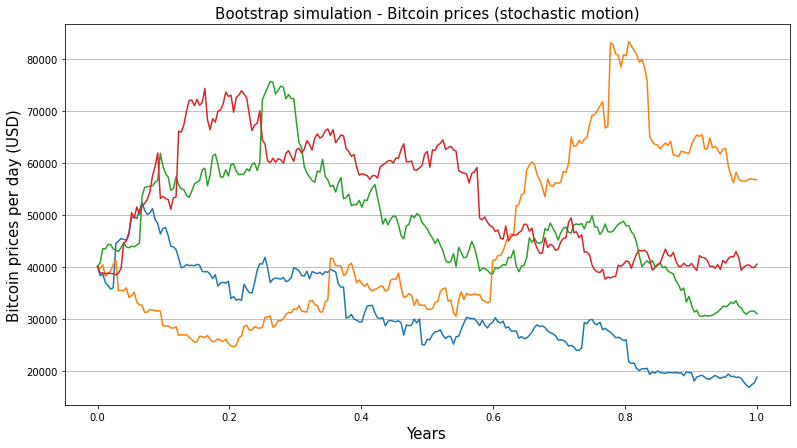

In [28]:
plt.figure(figsize=(13,7))
fontsize=15
plt.title('Bootstrap simulation - Bitcoin prices (stochastic motion)',fontsize=fontsize)
plt.xlabel('Years',fontsize=fontsize)
plt.ylabel('Bitcoin prices per day (USD)',fontsize=fontsize)
plt.grid(axis='y')
a = [ rn.randint(0,M) for j in range(1,5)]
for runer in a:
    plt.plot(np.arange(0,(T+h-u),h), Bitcoin[runer])